TITLE: Analyzing City Service Response Efficiency in Washington, D.C. (2025)

SOURCE:  [311 City Service Requests](https://opendata.dc.gov/datasets/DCGIS::311-city-service-requests-in-2025/explore)

DESCRIPTION: The dataset used in this project is Washington, D.C.’s 2025 311 City Service Requests dataset, which contains records of non-emergency service requests submitted by residents. It includes information such as service type, location, priority, and request dates. The dataset originally had 440,600 rows and 33 columns, and after cleaning, 19 key columns were kept for analysis. This dataset is useful for understanding city service demand and response patterns across different areas of Washington, D.C.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("service_requests.csv", low_memory=False)
df

,X,Y,SERVICEREQUESTID,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,...,WARD,XCOORD,YCOORD,LATITUDE,LONGITUDE,MARADDRESSREPOSITORYID,GLOBALID,CREATED,EDITED,OBJECTID
0,401366.06,134524.87,25-00000002,1438 K STREET SE,WASHINGTON,DC,20003.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 6,401366.06,134524.87,38.878555,-76.984257,63442,{2AA431E0-F9C7-766F-E063-792F520A1480},NaN,NaN,11865239
1,396942.87,140394.80,25-00000003,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,...,Ward 1,396942.87,140394.80,38.931430,-77.035259,234437,{2AA431E0-F9C8-766F-E063-792F520A1480},NaN,NaN,11865240
2,393757.08,140604.28,25-00000004,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 3,393757.08,140604.28,38.933299,-77.072003,328204,{2AA431E0-F9C9-766F-E063-792F520A1480},NaN,NaN,11865241
3,401561.80,133400.44,25-00000005,1728 16TH STREET SE,WASHINGTON,DC,20020.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 8,401561.80,133400.44,38.868426,-76.982003,56949,{2AA431E0-F9CA-766F-E063-792F520A1480},NaN,NaN,11865242
4,399909.21,137153.67,25-00000007,327 K STREET NE,WASHINGTON,DC,20002.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 6,399909.21,137153.67,38.902238,-77.001047,37329,{2AA431E0-F9CB-766F-E063-792F520A1480},NaN,NaN,11865243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440595,405313.27,136605.71,25-00790590,4409 FOOTE STREET NE,WASHINGTON,DC,20019.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 7,405313.27,136605.71,38.897285,-76.938750,22130,{474CDF61-A463-738F-E063-782F520AE1E7},NaN,NaN,12384949
440596,397986.86,138741.56,25-00790594,1924 8TH STREET NW,WASHINGTON,DC,20001.0,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,...,Ward 1,397986.86,138741.56,38.916540,-77.023213,310465,{4752BD6F-BE25-5078-E063-782F520A43A6},NaN,NaN,12384950
440597,405900.42,137525.60,26-00002433,1126 49TH STREET NE,WASHINGTON,DC,20019.0,S0451,Trash Cart - Delivery,SWMA- Solid Waste Management Admistration,...,Ward 7,405900.42,137525.60,38.905568,-76.931973,73433,{476F72B2-596D-2AC9-E063-792F520A59BB},NaN,NaN,12386295
440598,400922.08,135939.61,26-00002483,136 TENNESSEE AVENUE NE,WASHINGTON,DC,20002.0,S0322,Recycling- Information Request,SWMA- Solid Waste Management Admistration,...,Ward 6,400922.08,135939.61,38.891301,-76.989371,65762,{476FA855-744B-664B-E063-792F520ADCB4},NaN,NaN,12386321


In [5]:
df.shape

(440600, 33)

In [6]:
df.head(5)

,X,Y,SERVICEREQUESTID,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,...,WARD,XCOORD,YCOORD,LATITUDE,LONGITUDE,MARADDRESSREPOSITORYID,GLOBALID,CREATED,EDITED,OBJECTID
0,401366.06,134524.87,25-00000002,1438 K STREET SE,WASHINGTON,DC,20003.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 6,401366.06,134524.87,38.878555,-76.984257,63442,{2AA431E0-F9C7-766F-E063-792F520A1480},NaN,NaN,11865239
1,396942.87,140394.80,25-00000003,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,...,Ward 1,396942.87,140394.80,38.931430,-77.035259,234437,{2AA431E0-F9C8-766F-E063-792F520A1480},NaN,NaN,11865240
2,393757.08,140604.28,25-00000004,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 3,393757.08,140604.28,38.933299,-77.072003,328204,{2AA431E0-F9C9-766F-E063-792F520A1480},NaN,NaN,11865241
3,401561.80,133400.44,25-00000005,1728 16TH STREET SE,WASHINGTON,DC,20020.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 8,401561.80,133400.44,38.868426,-76.982003,56949,{2AA431E0-F9CA-766F-E063-792F520A1480},NaN,NaN,11865242
4,399909.21,137153.67,25-00000007,327 K STREET NE,WASHINGTON,DC,20002.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 6,399909.21,137153.67,38.902238,-77.001047,37329,{2AA431E0-F9CB-766F-E063-792F520A1480},NaN,NaN,11865243


In [7]:
df.columns

Index(['X', 'Y', 'SERVICEREQUESTID', 'STREETADDRESS', 'CITY', 'STATE',
       'ZIPCODE', 'SERVICECODE', 'SERVICECODEDESCRIPTION',
       'SERVICETYPECODEDESCRIPTION', 'ORGANIZATIONACRONYM', 'SERVICECALLCOUNT',
       'ADDDATE', 'RESOLUTIONDATE', 'SERVICEDUEDATE', 'SERVICEORDERDATE',
       'INSPECTIONFLAG', 'INSPECTIONDATE', 'INSPECTORNAME',
       'SERVICEORDERSTATUS', 'STATUS_CODE', 'PRIORITY', 'DETAILS', 'WARD',
       'XCOORD', 'YCOORD', 'LATITUDE', 'LONGITUDE', 'MARADDRESSREPOSITORYID',
       'GLOBALID', 'CREATED', 'EDITED', 'OBJECTID'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440600 entries, 0 to 440599
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   X                           440600 non-null  float64
 1   Y                           440600 non-null  float64
 2   SERVICEREQUESTID            440600 non-null  object 
 3   STREETADDRESS               437937 non-null  object 
 4   CITY                        440600 non-null  object 
 5   STATE                       440600 non-null  object 
 6   ZIPCODE                     440501 non-null  float64
 7   SERVICECODE                 440600 non-null  object 
 8   SERVICECODEDESCRIPTION      440600 non-null  object 
 9   SERVICETYPECODEDESCRIPTION  417735 non-null  object 
 10  ORGANIZATIONACRONYM         440445 non-null  object 
 11  SERVICECALLCOUNT            440600 non-null  int64  
 12  ADDDATE                     440600 non-null  object 
 13  RESOLUTIONDATE

In [9]:
print(df.columns.tolist())

['X', 'Y', 'SERVICEREQUESTID', 'STREETADDRESS', 'CITY', 'STATE', 'ZIPCODE', 'SERVICECODE', 'SERVICECODEDESCRIPTION', 'SERVICETYPECODEDESCRIPTION', 'ORGANIZATIONACRONYM', 'SERVICECALLCOUNT', 'ADDDATE', 'RESOLUTIONDATE', 'SERVICEDUEDATE', 'SERVICEORDERDATE', 'INSPECTIONFLAG', 'INSPECTIONDATE', 'INSPECTORNAME', 'SERVICEORDERSTATUS', 'STATUS_CODE', 'PRIORITY', 'DETAILS', 'WARD', 'XCOORD', 'YCOORD', 'LATITUDE', 'LONGITUDE', 'MARADDRESSREPOSITORYID', 'GLOBALID', 'CREATED', 'EDITED', 'OBJECTID']


In [10]:
cols_to_drop = [
    "INSPECTIONFLAG",
    "INSPECTIONDATE",
    "INSPECTORNAME",
    "STATUS_CODE",
    "CREATED",
    "EDITED"
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [11]:
df

,X,Y,SERVICEREQUESTID,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,...,PRIORITY,DETAILS,WARD,XCOORD,YCOORD,LATITUDE,LONGITUDE,MARADDRESSREPOSITORYID,GLOBALID,OBJECTID
0,401366.06,134524.87,25-00000002,1438 K STREET SE,WASHINGTON,DC,20003.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Standard,NaN,Ward 6,401366.06,134524.87,38.878555,-76.984257,63442,{2AA431E0-F9C7-766F-E063-792F520A1480},11865239
1,396942.87,140394.80,25-00000003,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,...,Standard,NaN,Ward 1,396942.87,140394.80,38.931430,-77.035259,234437,{2AA431E0-F9C8-766F-E063-792F520A1480},11865240
2,393757.08,140604.28,25-00000004,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Standard,NaN,Ward 3,393757.08,140604.28,38.933299,-77.072003,328204,{2AA431E0-F9C9-766F-E063-792F520A1480},11865241
3,401561.80,133400.44,25-00000005,1728 16TH STREET SE,WASHINGTON,DC,20020.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Standard,NaN,Ward 8,401561.80,133400.44,38.868426,-76.982003,56949,{2AA431E0-F9CA-766F-E063-792F520A1480},11865242
4,399909.21,137153.67,25-00000007,327 K STREET NE,WASHINGTON,DC,20002.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Standard,NaN,Ward 6,399909.21,137153.67,38.902238,-77.001047,37329,{2AA431E0-F9CB-766F-E063-792F520A1480},11865243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440595,405313.27,136605.71,25-00790590,4409 FOOTE STREET NE,WASHINGTON,DC,20019.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Standard,NaN,Ward 7,405313.27,136605.71,38.897285,-76.938750,22130,{474CDF61-A463-738F-E063-782F520AE1E7},12384949
440596,397986.86,138741.56,25-00790594,1924 8TH STREET NW,WASHINGTON,DC,20001.0,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,...,Standard,NaN,Ward 1,397986.86,138741.56,38.916540,-77.023213,310465,{4752BD6F-BE25-5078-E063-782F520A43A6},12384950
440597,405900.42,137525.60,26-00002433,1126 49TH STREET NE,WASHINGTON,DC,20019.0,S0451,Trash Cart - Delivery,SWMA- Solid Waste Management Admistration,...,Standard,NaN,Ward 7,405900.42,137525.60,38.905568,-76.931973,73433,{476F72B2-596D-2AC9-E063-792F520A59BB},12386295
440598,400922.08,135939.61,26-00002483,136 TENNESSEE AVENUE NE,WASHINGTON,DC,20002.0,S0322,Recycling- Information Request,SWMA- Solid Waste Management Admistration,...,Standard,NaN,Ward 6,400922.08,135939.61,38.891301,-76.989371,65762,{476FA855-744B-664B-E063-792F520ADCB4},12386321


In [12]:
print(df.isnull().sum())

X                                  0
Y                                  0
SERVICEREQUESTID                   0
STREETADDRESS                   2663
CITY                               0
STATE                              0
ZIPCODE                           99
SERVICECODE                        0
SERVICECODEDESCRIPTION             0
SERVICETYPECODEDESCRIPTION     22865
ORGANIZATIONACRONYM              155
SERVICECALLCOUNT                   0
ADDDATE                            0
RESOLUTIONDATE                  6120
SERVICEDUEDATE                    14
SERVICEORDERDATE                   0
SERVICEORDERSTATUS                 0
PRIORITY                          20
DETAILS                       439825
WARD                              10
XCOORD                             0
YCOORD                             0
LATITUDE                           0
LONGITUDE                          0
MARADDRESSREPOSITORYID             0
GLOBALID                           0
OBJECTID                           0
d

In [13]:
drop_cols = [
    "X","Y","XCOORD","YCOORD",
    "GLOBALID","OBJECTID",
    "MARADDRESSREPOSITORYID",
    "SERVICEREQUESTID",
    "SERVICECODE",
    "DETAILS"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [14]:
df

,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,ORGANIZATIONACRONYM,SERVICECALLCOUNT,ADDDATE,RESOLUTIONDATE,SERVICEDUEDATE,SERVICEORDERDATE,SERVICEORDERSTATUS,PRIORITY,WARD,LATITUDE,LONGITUDE
0,1438 K STREET SE,WASHINGTON,DC,20003.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:22:23+00,2025/01/25 16:50:59+00,2025/01/10 04:59:00+00,2025/01/01 05:22:23+00,Closed,Standard,Ward 6,38.878555,-76.984257
1,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2025/01/01 05:23:49+00,2025/01/01 05:42:41+00,2025/01/02 05:23:49+00,2025/01/01 05:23:49+00,Closed,Standard,Ward 1,38.931430,-77.035259
2,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:24:13+00,2025/01/14 17:46:20+00,2025/01/11 04:59:00+00,2025/01/01 05:24:13+00,Closed,Standard,Ward 3,38.933299,-77.072003
3,1728 16TH STREET SE,WASHINGTON,DC,20020.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:28:59+00,2025/01/23 17:57:19+00,2025/01/09 04:59:00+00,2025/01/01 05:28:59+00,Closed,Standard,Ward 8,38.868426,-76.982003
4,327 K STREET NE,WASHINGTON,DC,20002.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:29:54+00,2025/01/25 13:15:44+00,2025/01/10 04:59:00+00,2025/01/01 05:29:54+00,Closed,Standard,Ward 6,38.902238,-77.001047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440595,4409 FOOTE STREET NE,WASHINGTON,DC,20019.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2026/01/01 04:09:46+00,2026/01/13 14:39:35+00,2026/01/14 04:59:00+00,2026/01/01 04:09:46+00,Closed,Standard,Ward 7,38.897285,-76.938750
440596,1924 8TH STREET NW,WASHINGTON,DC,20001.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2026/01/01 04:55:33+00,2026/01/01 05:46:45+00,2026/01/03 04:55:33+00,2026/01/01 04:55:33+00,Closed,Standard,Ward 1,38.916540,-77.023213
440597,1126 49TH STREET NE,WASHINGTON,DC,20019.0,Trash Cart - Delivery,SWMA- Solid Waste Management Admistration,DPW,1,2025/12/26 17:40:34+00,2026/01/02 21:14:40+00,2026/01/27 17:40:34+00,2025/12/26 17:40:34+00,Closed (Transferred),Standard,Ward 7,38.905568,-76.931973
440598,136 TENNESSEE AVENUE NE,WASHINGTON,DC,20002.0,Recycling- Information Request,SWMA- Solid Waste Management Admistration,DPW,1,2025/12/29 23:10:22+00,2026/01/02 21:29:16+00,2026/01/06 23:10:22+00,2025/12/29 23:10:22+00,Closed (Transferred),Standard,Ward 6,38.891301,-76.989371


In [15]:
df["STREETADDRESS"] = df["STREETADDRESS"].fillna("Unknown")
df["ZIPCODE"] = df["ZIPCODE"].fillna(df["ZIPCODE"].mode()[0])
df["SERVICETYPECODEDESCRIPTION"] = df["SERVICETYPECODEDESCRIPTION"].fillna("Unknown")
df["ORGANIZATIONACRONYM"] = df["ORGANIZATIONACRONYM"].fillna("Unknown")
df["PRIORITY"] = df["PRIORITY"].fillna("Unknown")
df["WARD"] = df["WARD"].fillna("Unknown")


In [16]:
df

,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,ORGANIZATIONACRONYM,SERVICECALLCOUNT,ADDDATE,RESOLUTIONDATE,SERVICEDUEDATE,SERVICEORDERDATE,SERVICEORDERSTATUS,PRIORITY,WARD,LATITUDE,LONGITUDE
0,1438 K STREET SE,WASHINGTON,DC,20003.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:22:23+00,2025/01/25 16:50:59+00,2025/01/10 04:59:00+00,2025/01/01 05:22:23+00,Closed,Standard,Ward 6,38.878555,-76.984257
1,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2025/01/01 05:23:49+00,2025/01/01 05:42:41+00,2025/01/02 05:23:49+00,2025/01/01 05:23:49+00,Closed,Standard,Ward 1,38.931430,-77.035259
2,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:24:13+00,2025/01/14 17:46:20+00,2025/01/11 04:59:00+00,2025/01/01 05:24:13+00,Closed,Standard,Ward 3,38.933299,-77.072003
3,1728 16TH STREET SE,WASHINGTON,DC,20020.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:28:59+00,2025/01/23 17:57:19+00,2025/01/09 04:59:00+00,2025/01/01 05:28:59+00,Closed,Standard,Ward 8,38.868426,-76.982003
4,327 K STREET NE,WASHINGTON,DC,20002.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:29:54+00,2025/01/25 13:15:44+00,2025/01/10 04:59:00+00,2025/01/01 05:29:54+00,Closed,Standard,Ward 6,38.902238,-77.001047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440595,4409 FOOTE STREET NE,WASHINGTON,DC,20019.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2026/01/01 04:09:46+00,2026/01/13 14:39:35+00,2026/01/14 04:59:00+00,2026/01/01 04:09:46+00,Closed,Standard,Ward 7,38.897285,-76.938750
440596,1924 8TH STREET NW,WASHINGTON,DC,20001.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2026/01/01 04:55:33+00,2026/01/01 05:46:45+00,2026/01/03 04:55:33+00,2026/01/01 04:55:33+00,Closed,Standard,Ward 1,38.916540,-77.023213
440597,1126 49TH STREET NE,WASHINGTON,DC,20019.0,Trash Cart - Delivery,SWMA- Solid Waste Management Admistration,DPW,1,2025/12/26 17:40:34+00,2026/01/02 21:14:40+00,2026/01/27 17:40:34+00,2025/12/26 17:40:34+00,Closed (Transferred),Standard,Ward 7,38.905568,-76.931973
440598,136 TENNESSEE AVENUE NE,WASHINGTON,DC,20002.0,Recycling- Information Request,SWMA- Solid Waste Management Admistration,DPW,1,2025/12/29 23:10:22+00,2026/01/02 21:29:16+00,2026/01/06 23:10:22+00,2025/12/29 23:10:22+00,Closed (Transferred),Standard,Ward 6,38.891301,-76.989371


In [17]:
print(df.isnull().sum())

STREETADDRESS                    0
CITY                             0
STATE                            0
ZIPCODE                          0
SERVICECODEDESCRIPTION           0
SERVICETYPECODEDESCRIPTION       0
ORGANIZATIONACRONYM              0
SERVICECALLCOUNT                 0
ADDDATE                          0
RESOLUTIONDATE                6120
SERVICEDUEDATE                  14
SERVICEORDERDATE                 0
SERVICEORDERSTATUS               0
PRIORITY                         0
WARD                             0
LATITUDE                         0
LONGITUDE                        0
dtype: int64


In [18]:
df["Resolved"] = df["RESOLUTIONDATE"].notna()
df

,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,ORGANIZATIONACRONYM,SERVICECALLCOUNT,ADDDATE,RESOLUTIONDATE,SERVICEDUEDATE,SERVICEORDERDATE,SERVICEORDERSTATUS,PRIORITY,WARD,LATITUDE,LONGITUDE,Resolved
0,1438 K STREET SE,WASHINGTON,DC,20003.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:22:23+00,2025/01/25 16:50:59+00,2025/01/10 04:59:00+00,2025/01/01 05:22:23+00,Closed,Standard,Ward 6,38.878555,-76.984257,True
1,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2025/01/01 05:23:49+00,2025/01/01 05:42:41+00,2025/01/02 05:23:49+00,2025/01/01 05:23:49+00,Closed,Standard,Ward 1,38.931430,-77.035259,True
2,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:24:13+00,2025/01/14 17:46:20+00,2025/01/11 04:59:00+00,2025/01/01 05:24:13+00,Closed,Standard,Ward 3,38.933299,-77.072003,True
3,1728 16TH STREET SE,WASHINGTON,DC,20020.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:28:59+00,2025/01/23 17:57:19+00,2025/01/09 04:59:00+00,2025/01/01 05:28:59+00,Closed,Standard,Ward 8,38.868426,-76.982003,True
4,327 K STREET NE,WASHINGTON,DC,20002.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:29:54+00,2025/01/25 13:15:44+00,2025/01/10 04:59:00+00,2025/01/01 05:29:54+00,Closed,Standard,Ward 6,38.902238,-77.001047,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440595,4409 FOOTE STREET NE,WASHINGTON,DC,20019.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2026/01/01 04:09:46+00,2026/01/13 14:39:35+00,2026/01/14 04:59:00+00,2026/01/01 04:09:46+00,Closed,Standard,Ward 7,38.897285,-76.938750,True
440596,1924 8TH STREET NW,WASHINGTON,DC,20001.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2026/01/01 04:55:33+00,2026/01/01 05:46:45+00,2026/01/03 04:55:33+00,2026/01/01 04:55:33+00,Closed,Standard,Ward 1,38.916540,-77.023213,True
440597,1126 49TH STREET NE,WASHINGTON,DC,20019.0,Trash Cart - Delivery,SWMA- Solid Waste Management Admistration,DPW,1,2025/12/26 17:40:34+00,2026/01/02 21:14:40+00,2026/01/27 17:40:34+00,2025/12/26 17:40:34+00,Closed (Transferred),Standard,Ward 7,38.905568,-76.931973,True
440598,136 TENNESSEE AVENUE NE,WASHINGTON,DC,20002.0,Recycling- Information Request,SWMA- Solid Waste Management Admistration,DPW,1,2025/12/29 23:10:22+00,2026/01/02 21:29:16+00,2026/01/06 23:10:22+00,2025/12/29 23:10:22+00,Closed (Transferred),Standard,Ward 6,38.891301,-76.989371,True


In [19]:
df["RESOLUTIONDATE"].isna().sum()

np.int64(6120)

In [20]:
df["Resolved"].value_counts() #To show how many cases were resolved (true) and unresolved (False)

Resolved
True     434480
False      6120
Name: count, dtype: int64

In [21]:
df.groupby("WARD")["Resolved"].mean() #This shows a percentage of the cases that were resolved by ward. For example, Ward 1 had about 98% cases resolved. 

WARD
Unknown    1.000000
Ward 1     0.986040
Ward 2     0.980948
Ward 3     0.981179
Ward 4     0.988323
Ward 5     0.984780
Ward 6     0.987786
Ward 7     0.986835
Ward 8     0.992039
Name: Resolved, dtype: float64

### What are the most common types of service requests?

In [22]:
top_requests = df["SERVICECODEDESCRIPTION"].value_counts().head(10)
top_requests

SERVICECODEDESCRIPTION
Bulk Collection                         67414
Parking Enforcement                     58149
Scheduled Yard Waste                    36011
Trash Collection - Missed               25722
DC Government Information               18455
Recycling Collection - Missed           16985
Rodent Inspection and Treatment         16684
Illegal Dumping                         16678
Residential Parking Permit Violation    15283
Sanitation Enforcement                  14853
Name: count, dtype: int64

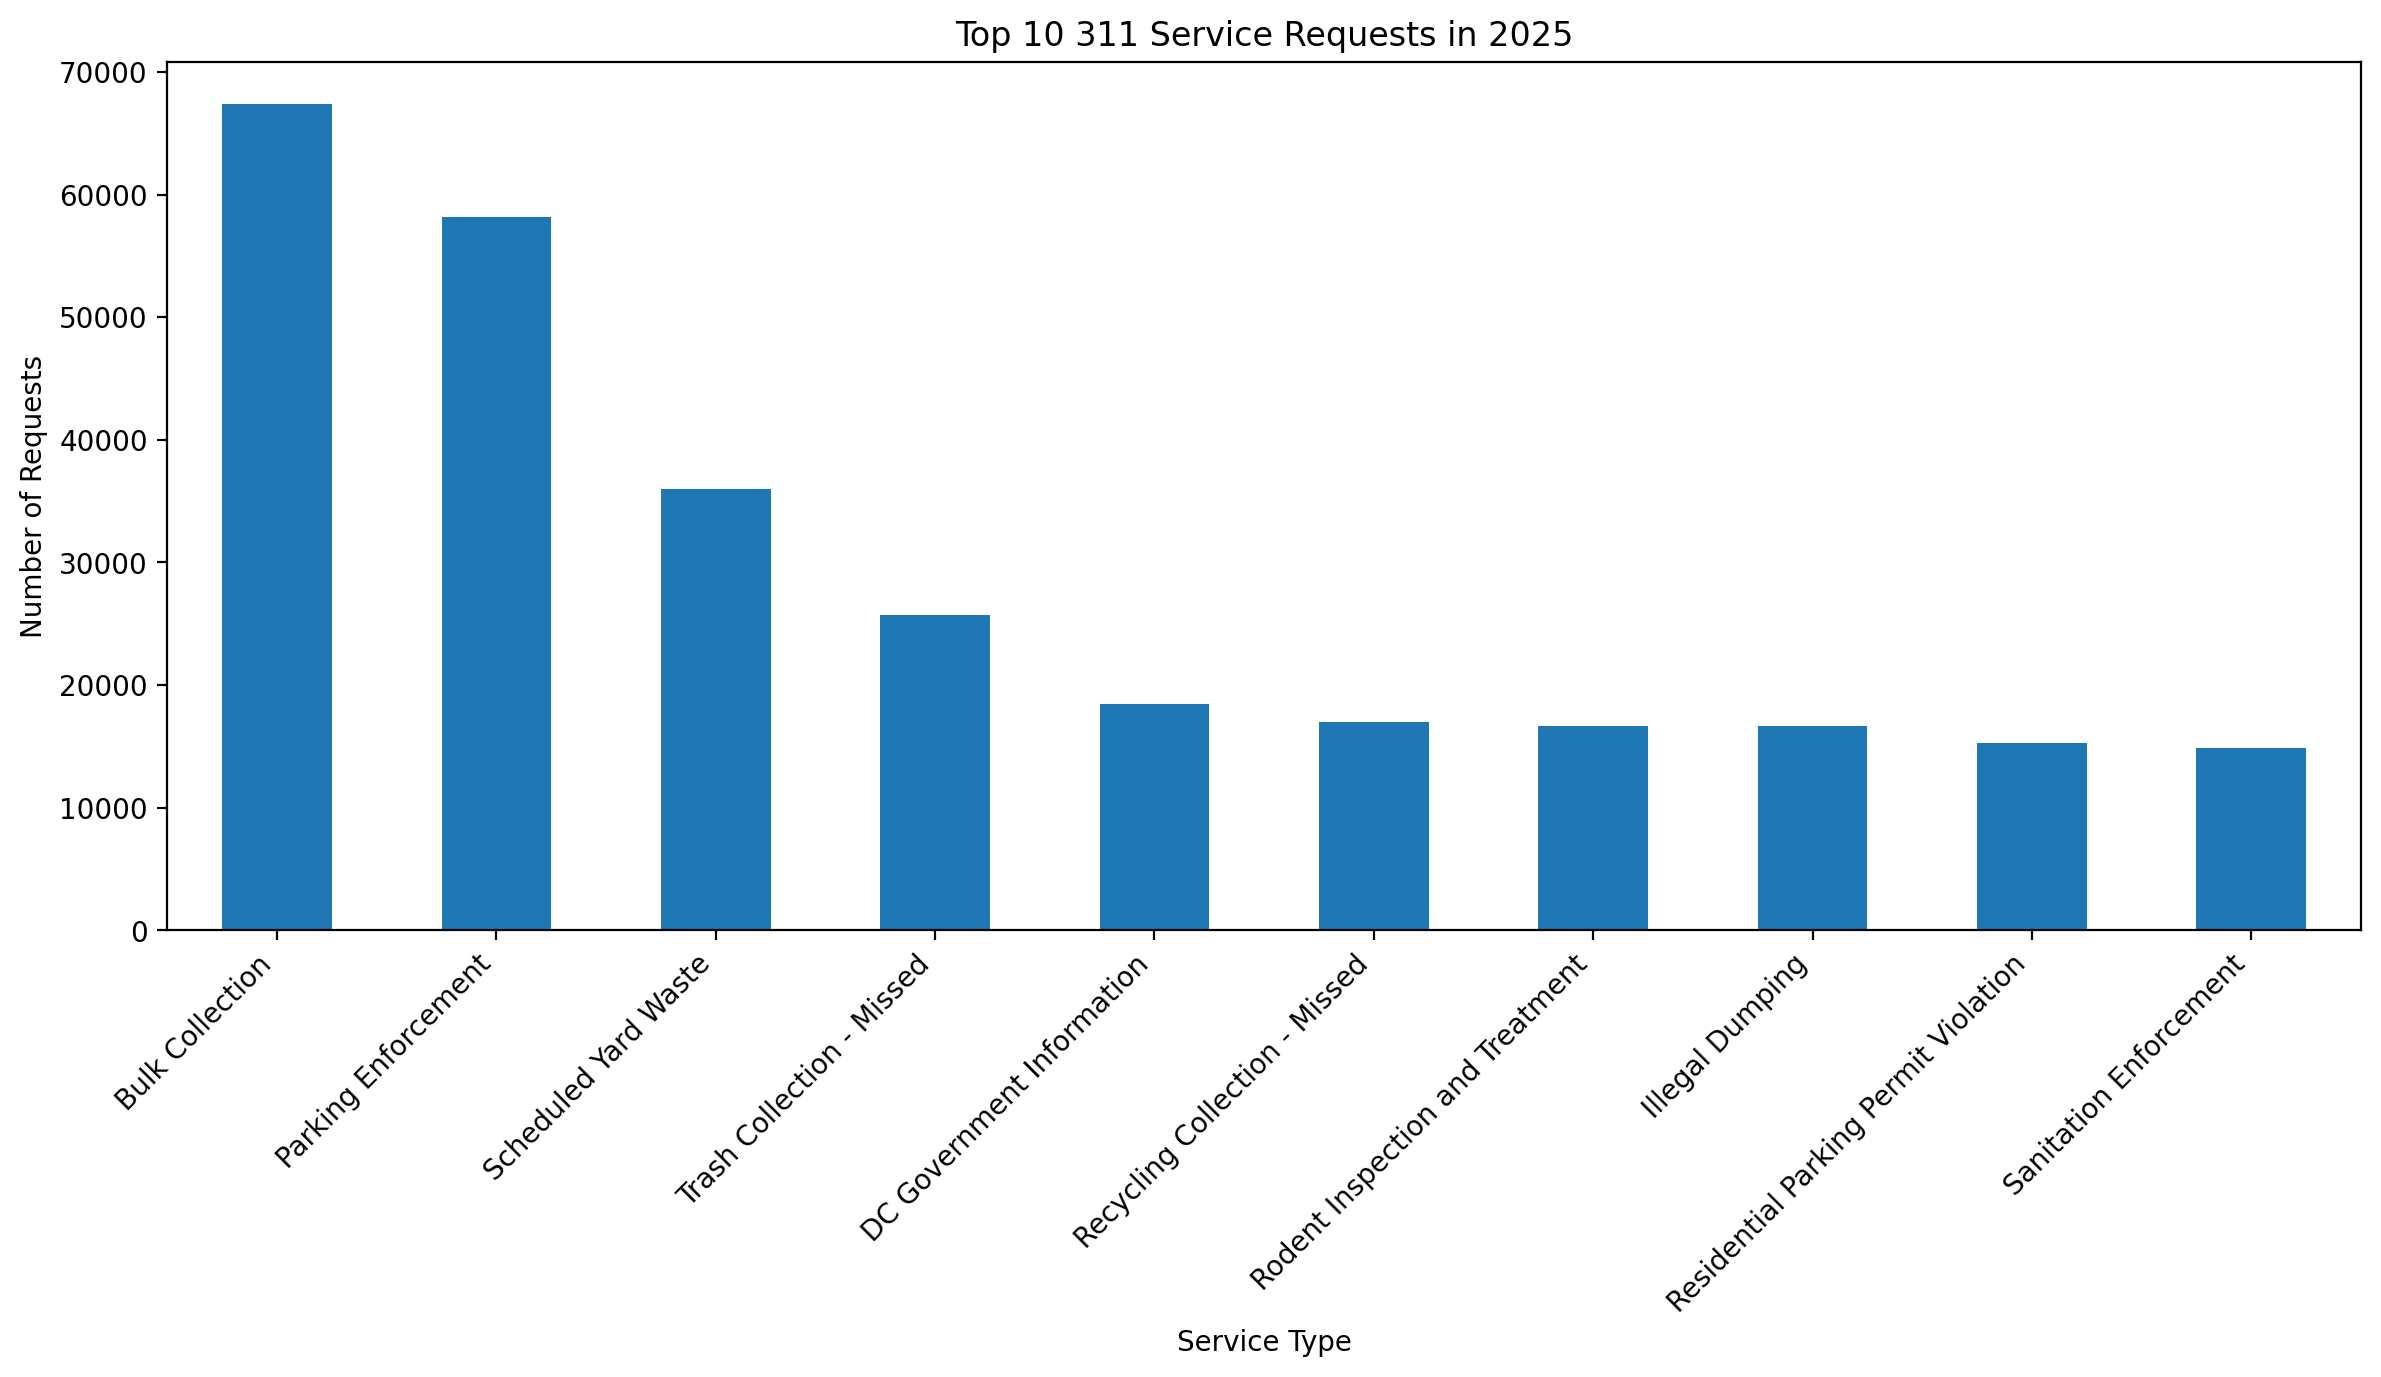

In [23]:
top_requests.plot(kind="bar")

plt.title("Top 10 311 Service Requests in 2025")
plt.xlabel("Service Type")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

##### The distribution of 311 service requests was analyzed to identify the most frequently reported issues in 2025. A bar chart of the top 10 service types shows that Bulk Collection is the most common concern reported by residents. This suggests that this issue represents the primary areas of public service demand.

## Where are the problems happening? (WARD analysis)

In [24]:
ward_rate = df["WARD"].value_counts(normalize=True) * 100
ward_rate.sort_index()

WARD
Unknown     0.002270
Ward 1     11.819337
Ward 2     11.162279
Ward 3      9.490695
Ward 4     14.791194
Ward 5     15.195188
Ward 6     14.550159
Ward 7     13.067635
Ward 8      9.921244
Name: proportion, dtype: float64

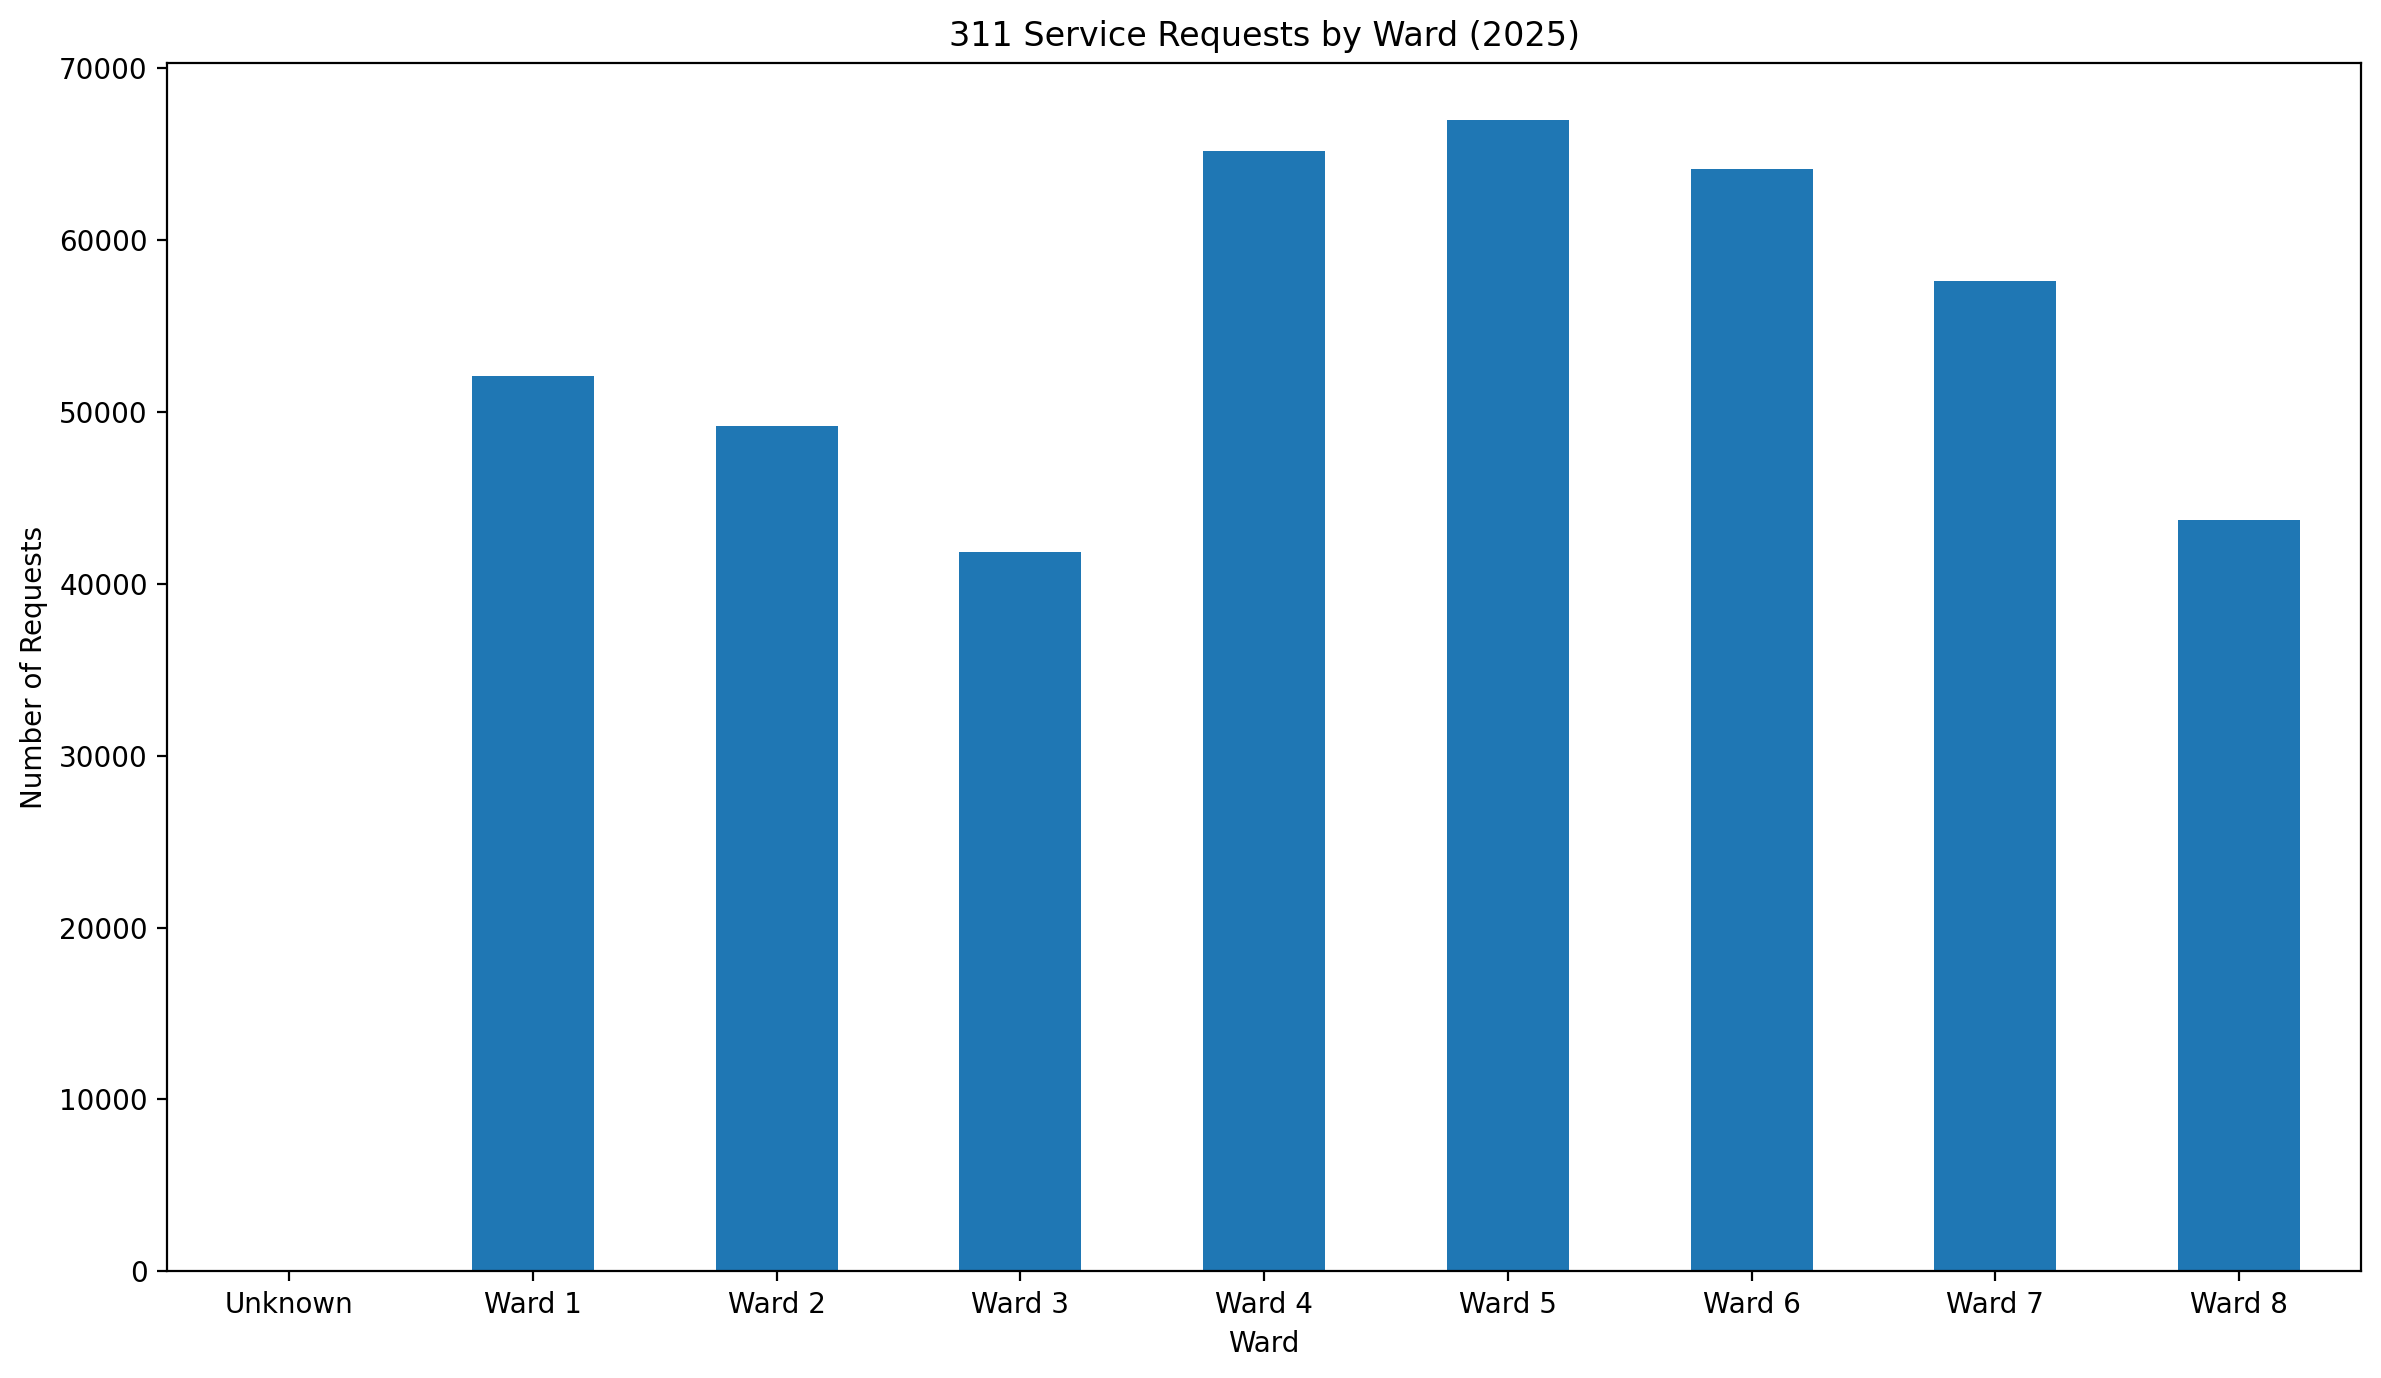

In [25]:
ward_counts = df["WARD"].value_counts().sort_index()

ward_counts.plot(kind="bar")

plt.title("311 Service Requests by Ward (2025)")
plt.xlabel("Ward")
plt.ylabel("Number of Requests")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##### This shows Ward 5 generates the most 311 service requests

### How long does it take to resolve service requests?

In [26]:
df["ADDDATE"] = pd.to_datetime(df["ADDDATE"], errors="coerce")
df["RESOLUTIONDATE"] = pd.to_datetime(df["RESOLUTIONDATE"], errors="coerce") # To convert date columns in text strings to actual dates that can be used for calculations.

In [27]:
df["Resolution_Time_Days"] = (
    df["RESOLUTIONDATE"] - df["ADDDATE"]
).dt.days

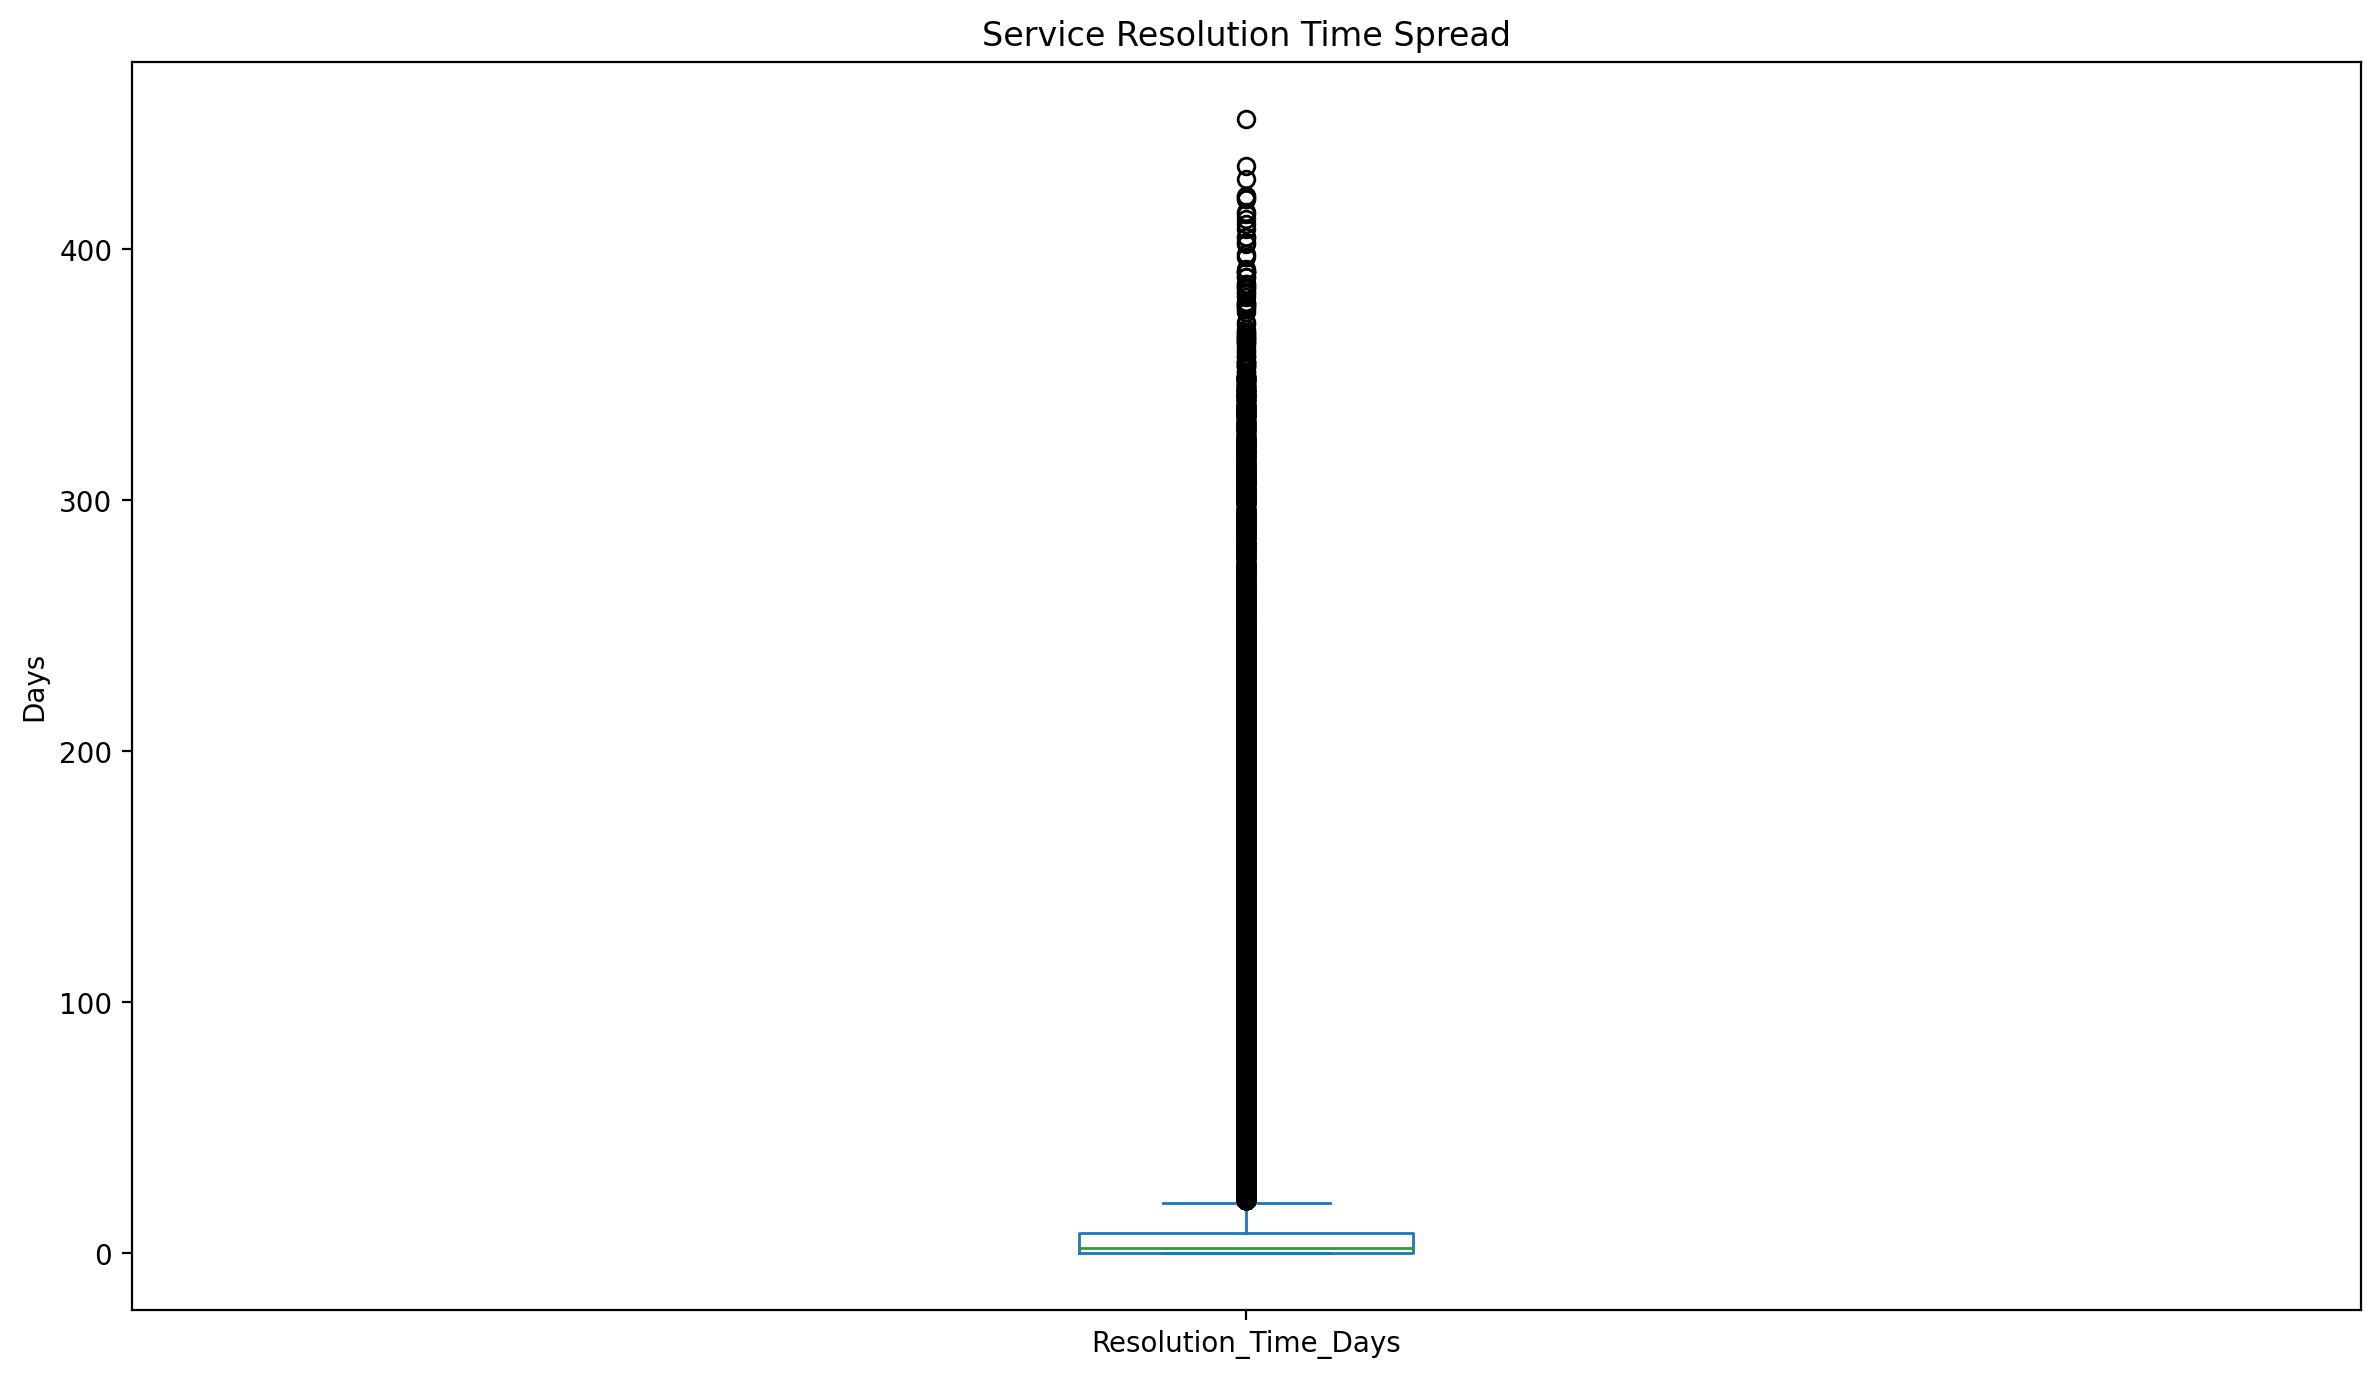

In [28]:
df["Resolution_Time_Days"].dropna().plot(kind="box")

plt.title("Service Resolution Time Spread")
plt.ylabel("Days")

plt.tight_layout()
plt.show()

##### The plot shows majority of the cases were resolved in a very quick manner. The top circles showed some cases took some more time to get resolved. 

#### Which wards report which problems the most?

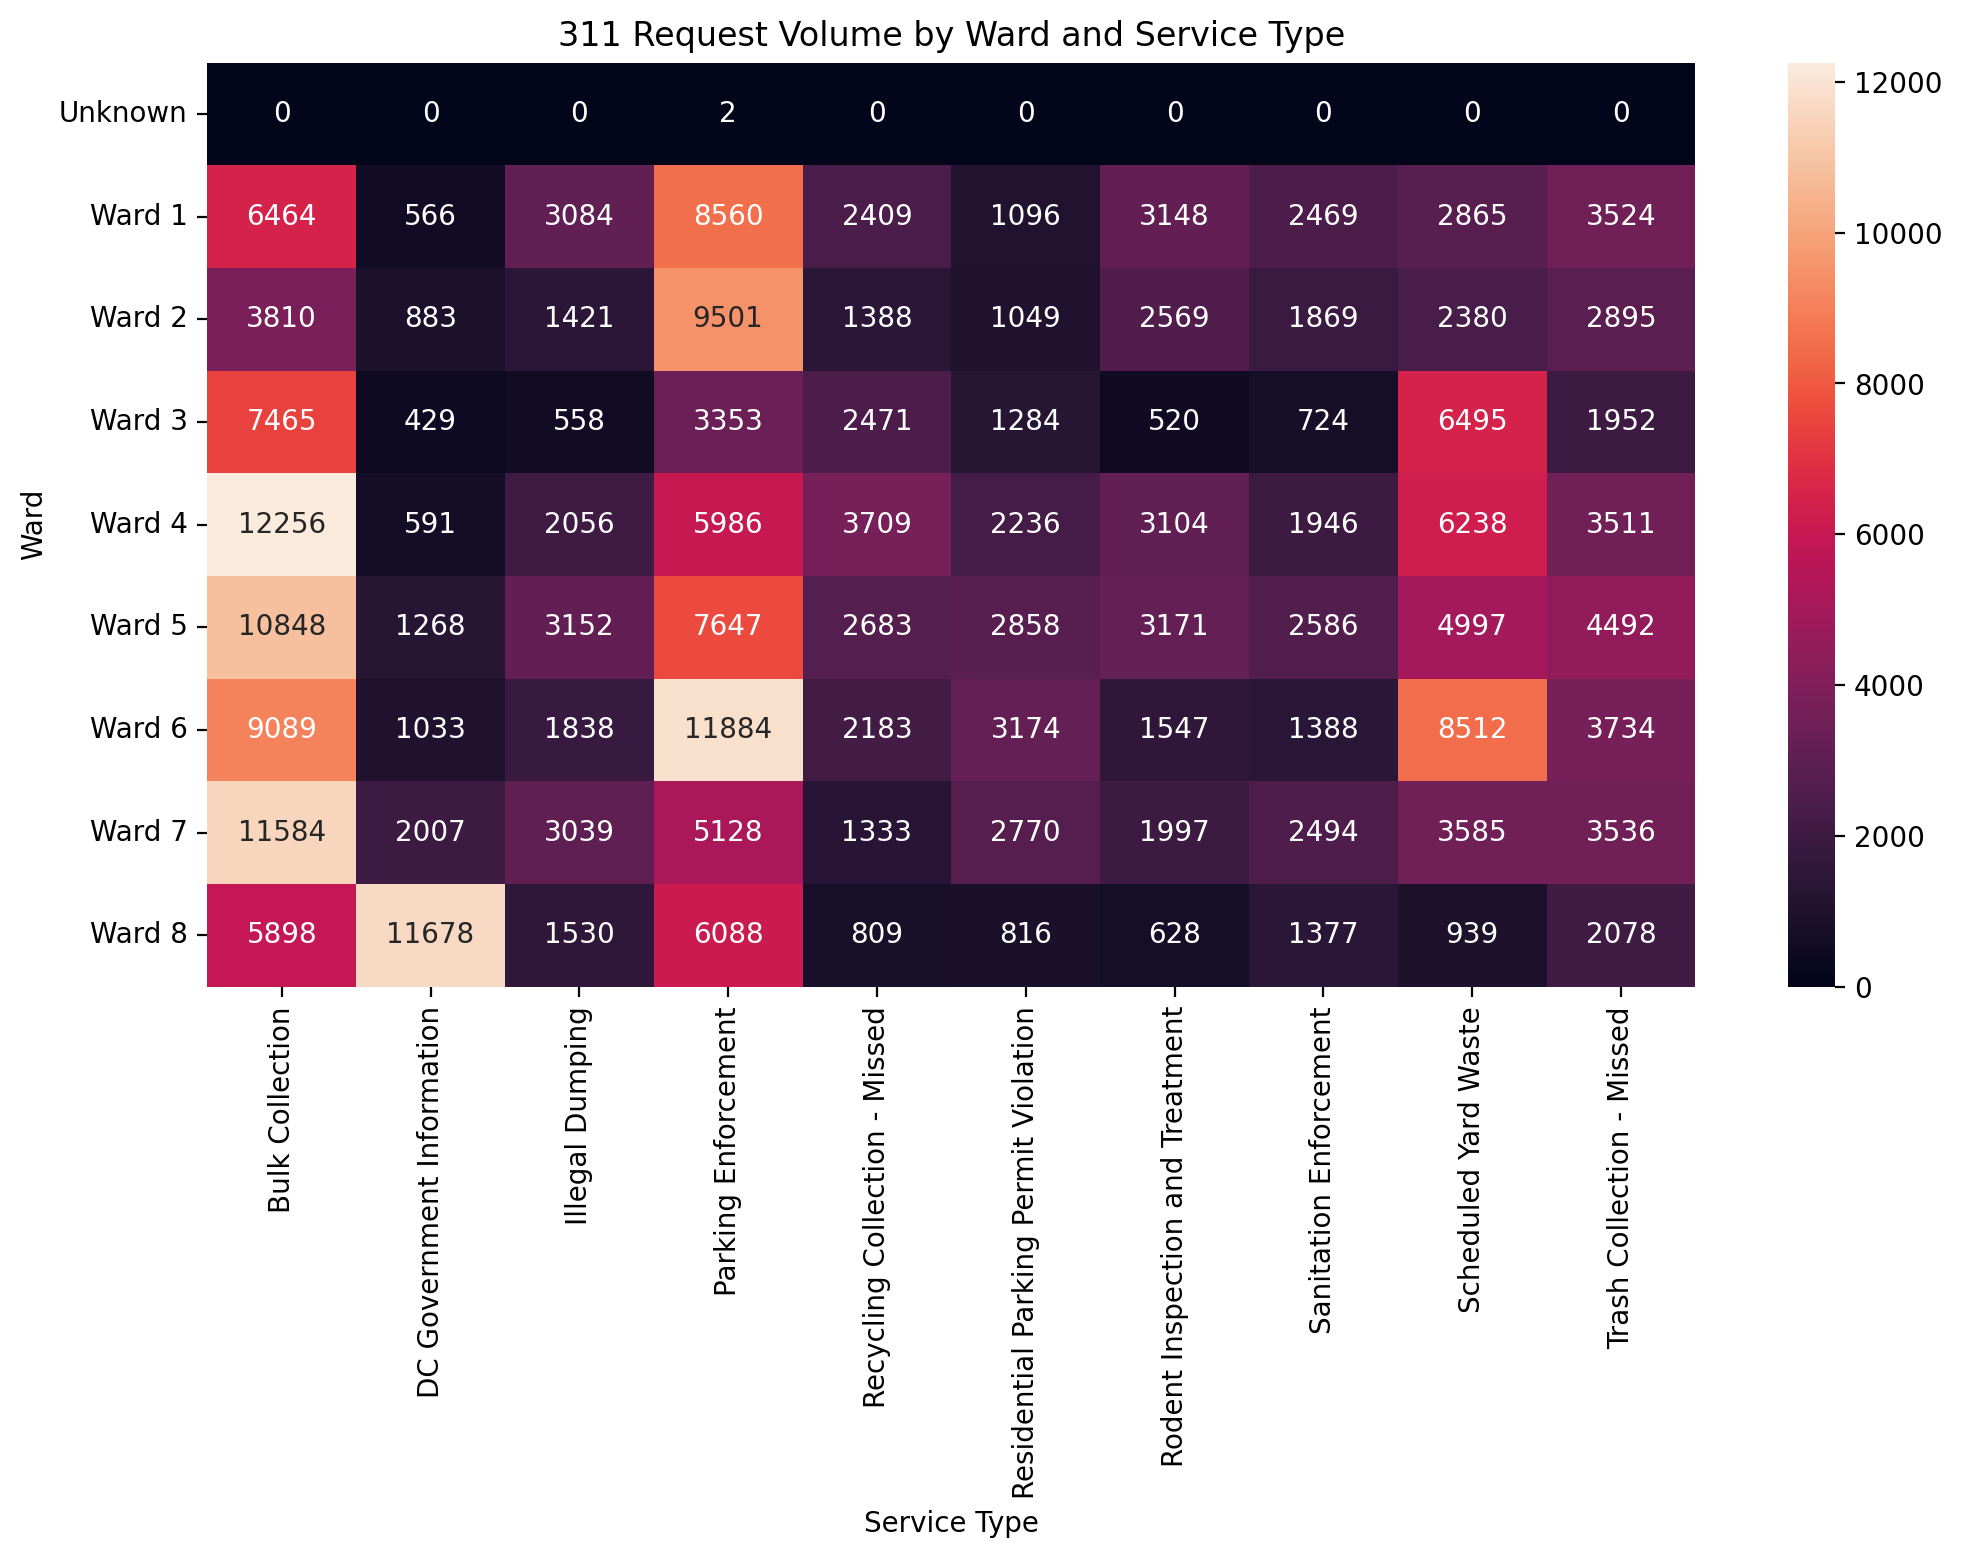

In [29]:
top_services = df["SERVICECODEDESCRIPTION"].value_counts().head(10).index

# filter to only top services
heat_df = df[df["SERVICECODEDESCRIPTION"].isin(top_services)]

# create grouped table
heat_data = heat_df.groupby(
    ["WARD", "SERVICECODEDESCRIPTION"]
).size().unstack(fill_value=0)

# plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heat_data, annot=True, fmt="d")

plt.title("311 Request Volume by Ward and Service Type")
plt.xlabel("Service Type")
plt.ylabel("Ward")
plt.show()

#### Which service types take the longest to resolve?

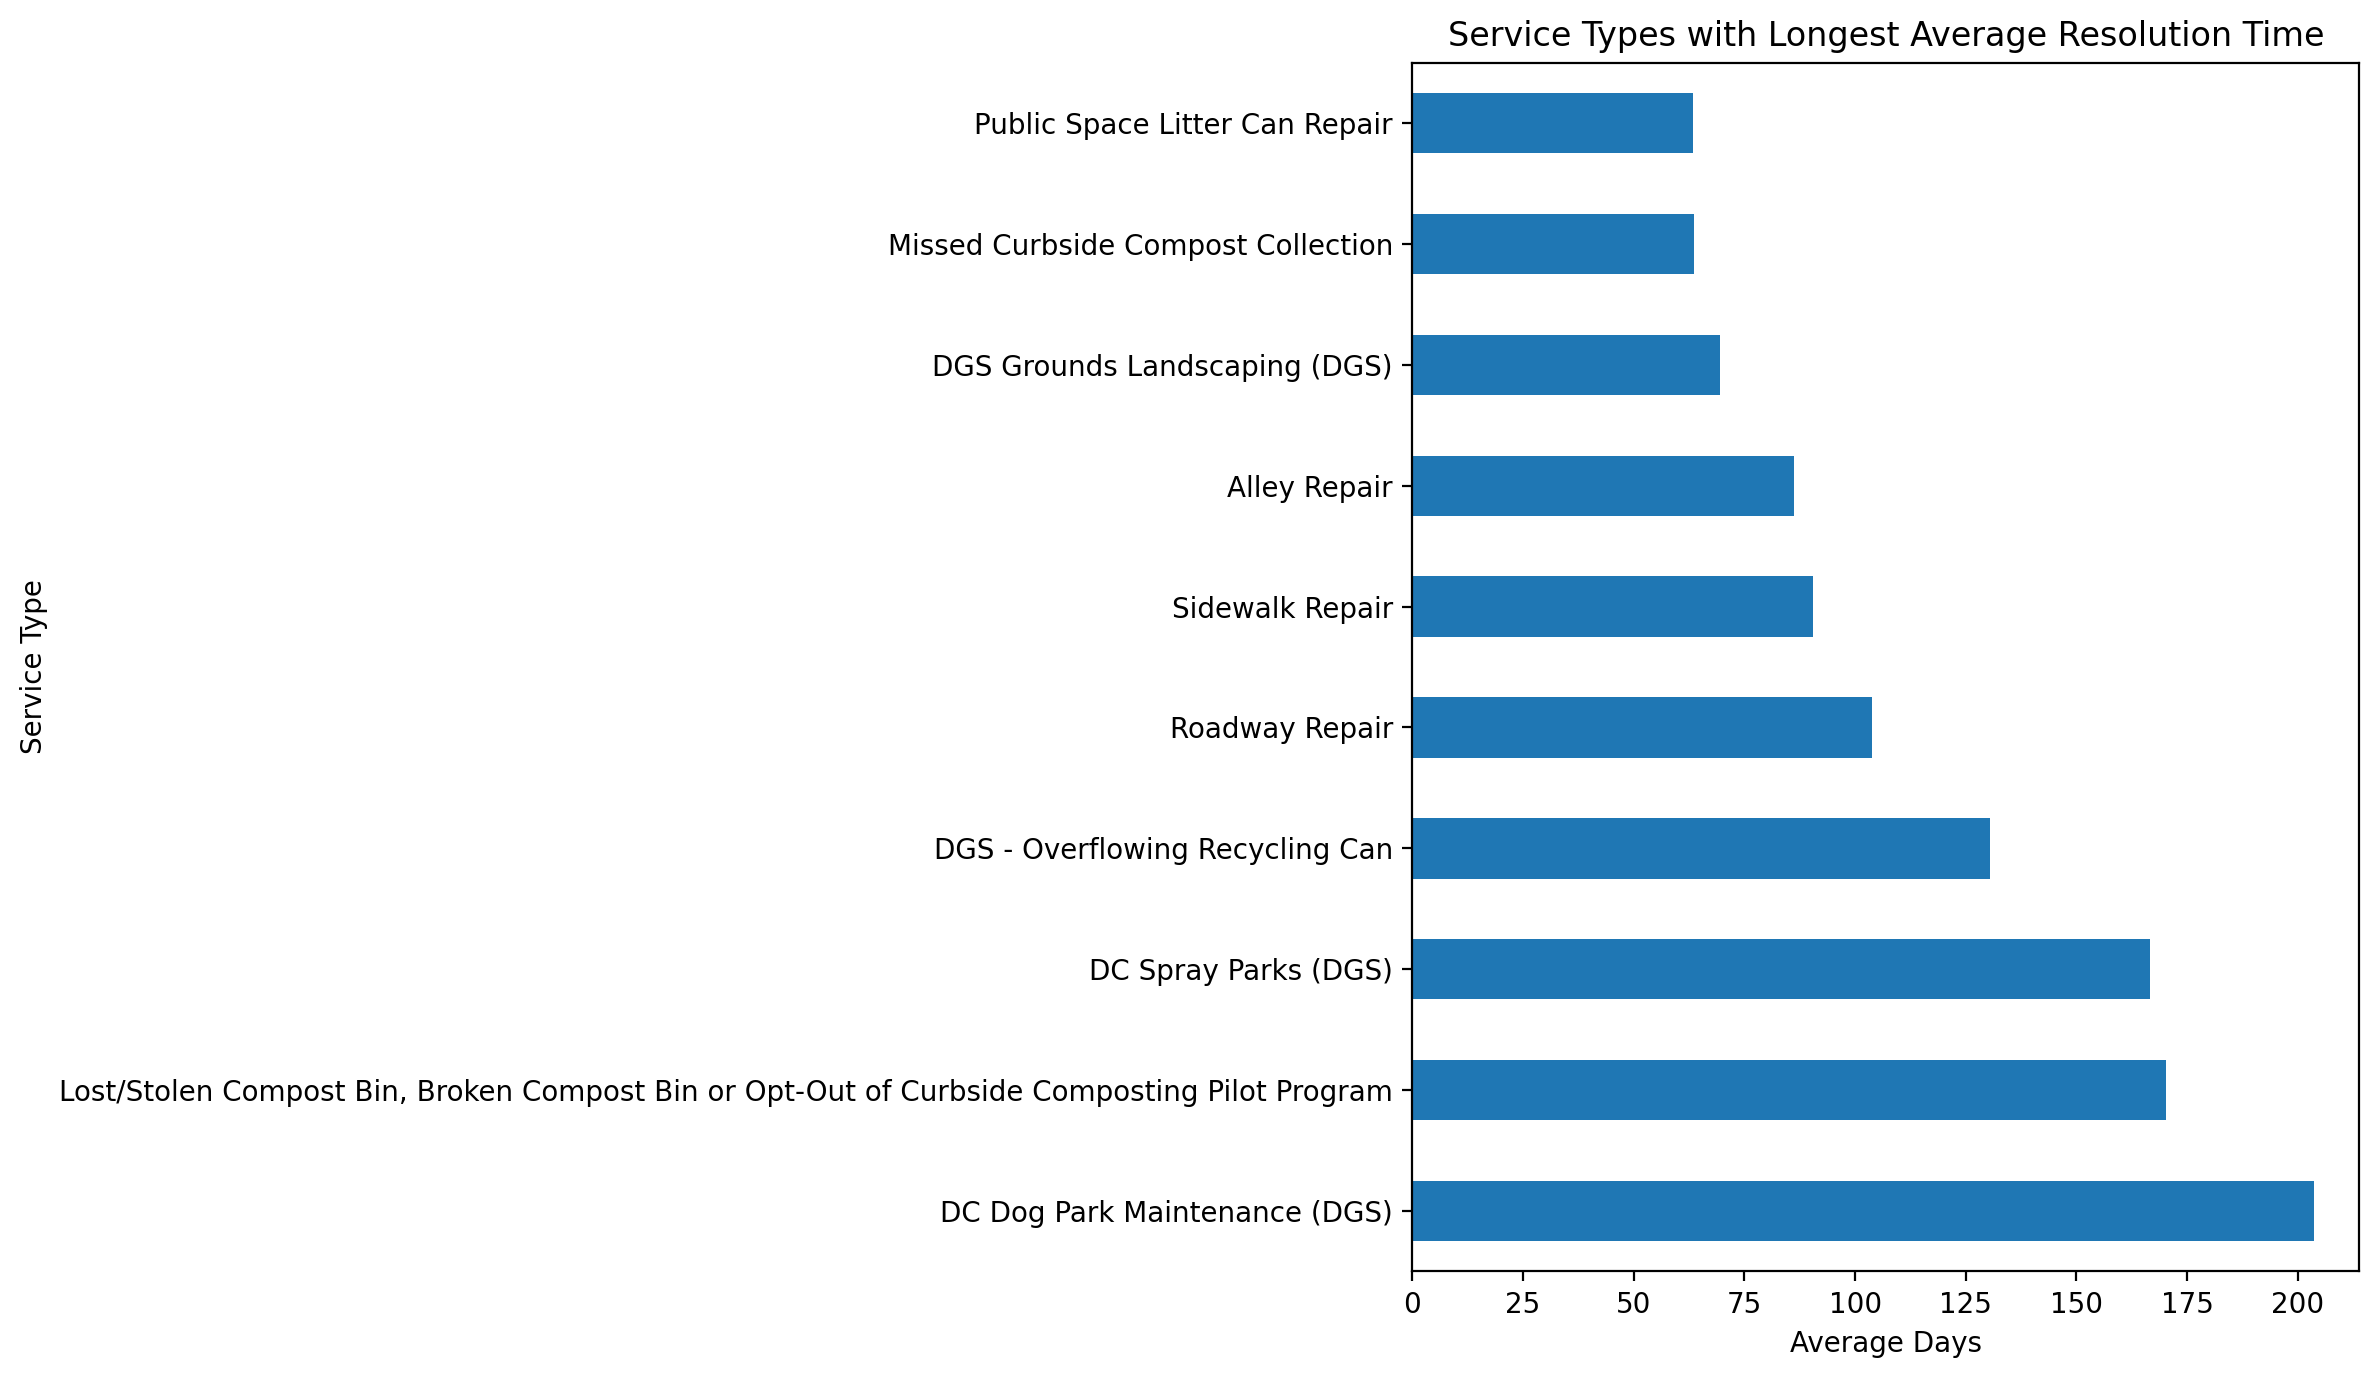

In [30]:
filtered = df.groupby("SERVICECODEDESCRIPTION").filter(lambda x: len(x) >= 100)

avg_resolution = (
    filtered.groupby("SERVICECODEDESCRIPTION")["Resolution_Time_Days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_resolution.plot(kind="barh")

plt.title("Service Types with Longest Average Resolution Time")
plt.xlabel("Average Days")
plt.ylabel("Service Type")

plt.tight_layout()
plt.show()

In [31]:
df

,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,ORGANIZATIONACRONYM,SERVICECALLCOUNT,ADDDATE,RESOLUTIONDATE,SERVICEDUEDATE,SERVICEORDERDATE,SERVICEORDERSTATUS,PRIORITY,WARD,LATITUDE,LONGITUDE,Resolved,Resolution_Time_Days
0,1438 K STREET SE,WASHINGTON,DC,20003.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025-01-01 05:22:23+00:00,2025-01-25 16:50:59+00:00,2025/01/10 04:59:00+00,2025/01/01 05:22:23+00,Closed,Standard,Ward 6,38.878555,-76.984257,True,24.0
1,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2025-01-01 05:23:49+00:00,2025-01-01 05:42:41+00:00,2025/01/02 05:23:49+00,2025/01/01 05:23:49+00,Closed,Standard,Ward 1,38.931430,-77.035259,True,0.0
2,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025-01-01 05:24:13+00:00,2025-01-14 17:46:20+00:00,2025/01/11 04:59:00+00,2025/01/01 05:24:13+00,Closed,Standard,Ward 3,38.933299,-77.072003,True,13.0
3,1728 16TH STREET SE,WASHINGTON,DC,20020.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025-01-01 05:28:59+00:00,2025-01-23 17:57:19+00:00,2025/01/09 04:59:00+00,2025/01/01 05:28:59+00,Closed,Standard,Ward 8,38.868426,-76.982003,True,22.0
4,327 K STREET NE,WASHINGTON,DC,20002.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025-01-01 05:29:54+00:00,2025-01-25 13:15:44+00:00,2025/01/10 04:59:00+00,2025/01/01 05:29:54+00,Closed,Standard,Ward 6,38.902238,-77.001047,True,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440595,4409 FOOTE STREET NE,WASHINGTON,DC,20019.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2026-01-01 04:09:46+00:00,2026-01-13 14:39:35+00:00,2026/01/14 04:59:00+00,2026/01/01 04:09:46+00,Closed,Standard,Ward 7,38.897285,-76.938750,True,12.0
440596,1924 8TH STREET NW,WASHINGTON,DC,20001.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2026-01-01 04:55:33+00:00,2026-01-01 05:46:45+00:00,2026/01/03 04:55:33+00,2026/01/01 04:55:33+00,Closed,Standard,Ward 1,38.916540,-77.023213,True,0.0
440597,1126 49TH STREET NE,WASHINGTON,DC,20019.0,Trash Cart - Delivery,SWMA- Solid Waste Management Admistration,DPW,1,2025-12-26 17:40:34+00:00,2026-01-02 21:14:40+00:00,2026/01/27 17:40:34+00,2025/12/26 17:40:34+00,Closed (Transferred),Standard,Ward 7,38.905568,-76.931973,True,7.0
440598,136 TENNESSEE AVENUE NE,WASHINGTON,DC,20002.0,Recycling- Information Request,SWMA- Solid Waste Management Admistration,DPW,1,2025-12-29 23:10:22+00:00,2026-01-02 21:29:16+00:00,2026/01/06 23:10:22+00,2025/12/29 23:10:22+00,Closed (Transferred),Standard,Ward 6,38.891301,-76.989371,True,3.0


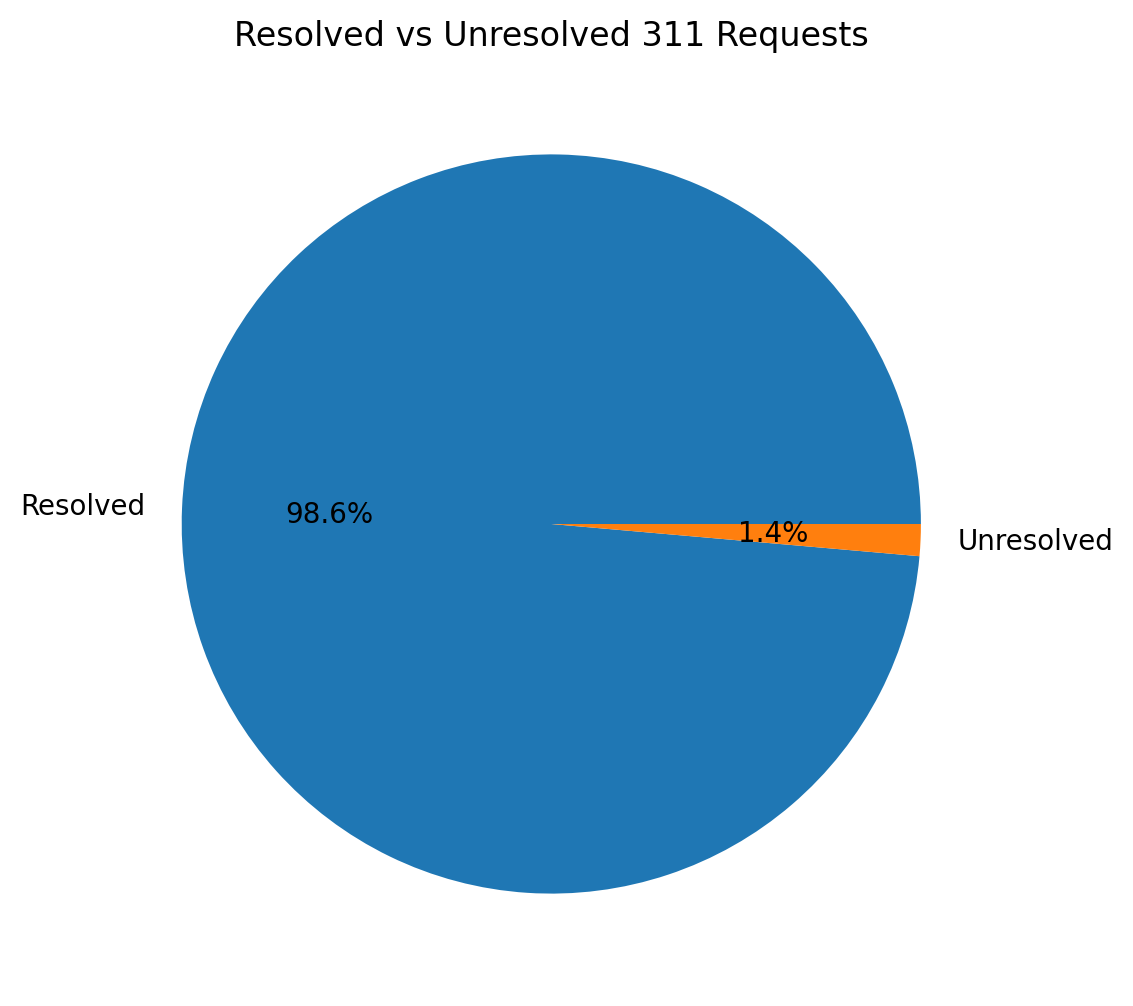

In [32]:
resolved_counts = df["Resolved"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(resolved_counts, labels=["Resolved", "Unresolved"], autopct="%1.1f%%")

plt.title("Resolved vs Unresolved 311 Requests")
plt.show()

##### The plot shows majority of the cases were resolved

In [33]:
df.duplicated().sum()

np.int64(4)

In [34]:
df.shape

(440600, 19)

In [35]:
df.to_csv('Alexander_Tewobola_final_project.csv', index=False)